In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import cheby1, sosfiltfilt
from tqdm import tqdm
import time
from pathlib import Path

In [2]:
trace_num = 2000
order = '3'
opt = 'o3'  # o0 or o3
scope = ''  # _chipwhisperer or space
algo = 'PQClean'  # orgPoly or PQClean or pqm4
platform = 'CW308_STM32F4'  # CW308_STM32F3 or CW308_STM32F4 or CWLITEARM

# 構建檔案路徑
trace_path = f'traces{scope}/{trace_num}/traces_unfixed_message_{trace_num}_{platform}_{opt}_{algo}_{order}'

# t = np.load(f'{trace_path}/trace.npy')
t = np.load(f'trytrace.npy')
m = np.load(f'{trace_path}/message.npy')

In [3]:
print(t.shape)
print(m.shape)
print(m)

(2000, 225000)
(2000, 32)
[[116. 224.  11. ...   5. 141.  26.]
 [252.   7. 243. ...  58.  26.  43.]
 [ 22.  73.   3. ... 166.  16. 124.]
 ...
 [101.  94. 126. ... 250.  70.  99.]
 [  4.  99. 150. ... 140. 211. 153.]
 [211. 254. 103. ...  72. 192.  66.]]


In [4]:
# 柴比雪夫濾波器參數
# fs = 500e6          # 採樣頻率 (Hz)
fs = 7.36e6          # 採樣頻率 (Hz)

cutoff_freq = 1000e3   # 截止頻率 (Hz)
filter_order = 5   # 濾波器階數
rp = 1.0            # 通帶最大波動 (dB)，例如 1 dB
# 計算正規化截止頻率
nyquist = fs / 2
normal_cutoff = cutoff_freq / nyquist

print(f"🔧 Chebyshev Type I 濾波器參數:")
print(f"  採樣頻率: {fs:.0f} Hz")
print(f"  截止頻率: {cutoff_freq:.0f} Hz")
print(f"  濾波器階數: {filter_order}")
print(f"  通帶最大波動 (rp): {rp} dB")
print(f"  正規化截止頻率: {normal_cutoff:.3f}")

🔧 Chebyshev Type I 濾波器參數:
  採樣頻率: 7360000 Hz
  截止頻率: 1000000 Hz
  濾波器階數: 5
  通帶最大波動 (rp): 1.0 dB
  正規化截止頻率: 0.272


In [5]:
sos = cheby1(filter_order, rp, normal_cutoff, btype='low', analog=False, output='sos')

In [6]:
filtered_traces_array = np.zeros_like(t)
failed_count = 0

# 使用進度條顯示處理進度
for i in tqdm(range(len(t)), desc="濾波處理 (SOS)"):
    try:
        filtered_traces_array[i] = sosfiltfilt(sos, t[i])
    except Exception as e:
        print(f"❌ 軌跡 {i} 處理失敗: {e}")
        failed_count += 1
        filtered_traces_array[i] = t[i]  # 或 np.zeros_like(t[i])

print(f"\n✅ 濾波處理完成!")
print(f"  成功處理: {len(t) - failed_count} 條")
print(f"  處理失敗: {failed_count} 條")

濾波處理 (SOS): 100%|██████████████████████████████████████████████████████████████| 2000/2000 [00:05<00:00, 339.48it/s]


✅ 濾波處理完成!
  成功處理: 2000 條
  處理失敗: 0 條


In [7]:
filter_name = 'ChebyshevI_lowpass'
cutoff_freq_MHz = int(cutoff_freq / 1e3)  # 轉換為整數 7
output_dir = f'traces_{filter_name}/cf{cutoff_freq_MHz}K_order{filter_order}'
output_path = Path(output_dir)
output_path.mkdir(parents=True, exist_ok=True)

# 保存濾波後的軌跡
trace_output_file = output_path / "trace.npy"
np.save(trace_output_file, filtered_traces_array)
print(f"✅ 濾波軌跡已保存: {trace_output_file}")

# 保存對應的訊息數據
message_output_file = output_path / "message.npy"
np.save(message_output_file, m)
print(f"✅ 訊息數據已保存: {message_output_file}")
print(filtered_traces_array.shape)
print(m.shape)

✅ 濾波軌跡已保存: traces_ChebyshevI_lowpass/cf1000K_order5/trace.npy
✅ 訊息數據已保存: traces_ChebyshevI_lowpass/cf1000K_order5/message.npy
(2000, 225000)
(2000, 32)


In [8]:
info_file = output_path / "filter_info.txt"
with open(info_file, 'w', encoding='utf-8') as f:
    f.write(f"Chebyshev Type I 濾波器處理資訊\n")
    f.write(f"========================\n")
    f.write(f"原始數據路徑: {trace_path}\n")
    f.write(f"濾波器類型: Butterworth 低通濾波器\n")
    f.write(f"截止頻率: {cutoff_freq} Hz\n")
    f.write(f"濾波器階數: {filter_order}\n")
    f.write(f"採樣頻率: {fs} Hz\n")
    f.write(f"原始軌跡數: {len(t)}\n")
    f.write(f"濾波軌跡數: {len(filtered_traces_array)}\n")

print(f"✅ 濾波器資訊已保存: {info_file}")
print(f"📁 所有檔案已保存至: {output_path}")

✅ 濾波器資訊已保存: traces_ChebyshevI_lowpass/cf1000K_order5/filter_info.txt
📁 所有檔案已保存至: traces_ChebyshevI_lowpass/cf1000K_order5


In [9]:
print(filtered_traces_array[0])
print(m)

[-0.1346887  -0.08081208 -0.0381283  ...  0.03288135  0.04040625
  0.04909412]
[[116. 224.  11. ...   5. 141.  26.]
 [252.   7. 243. ...  58.  26.  43.]
 [ 22.  73.   3. ... 166.  16. 124.]
 ...
 [101.  94. 126. ... 250.  70.  99.]
 [  4.  99. 150. ... 140. 211. 153.]
 [211. 254. 103. ...  72. 192.  66.]]


#### 濾波後單條trace

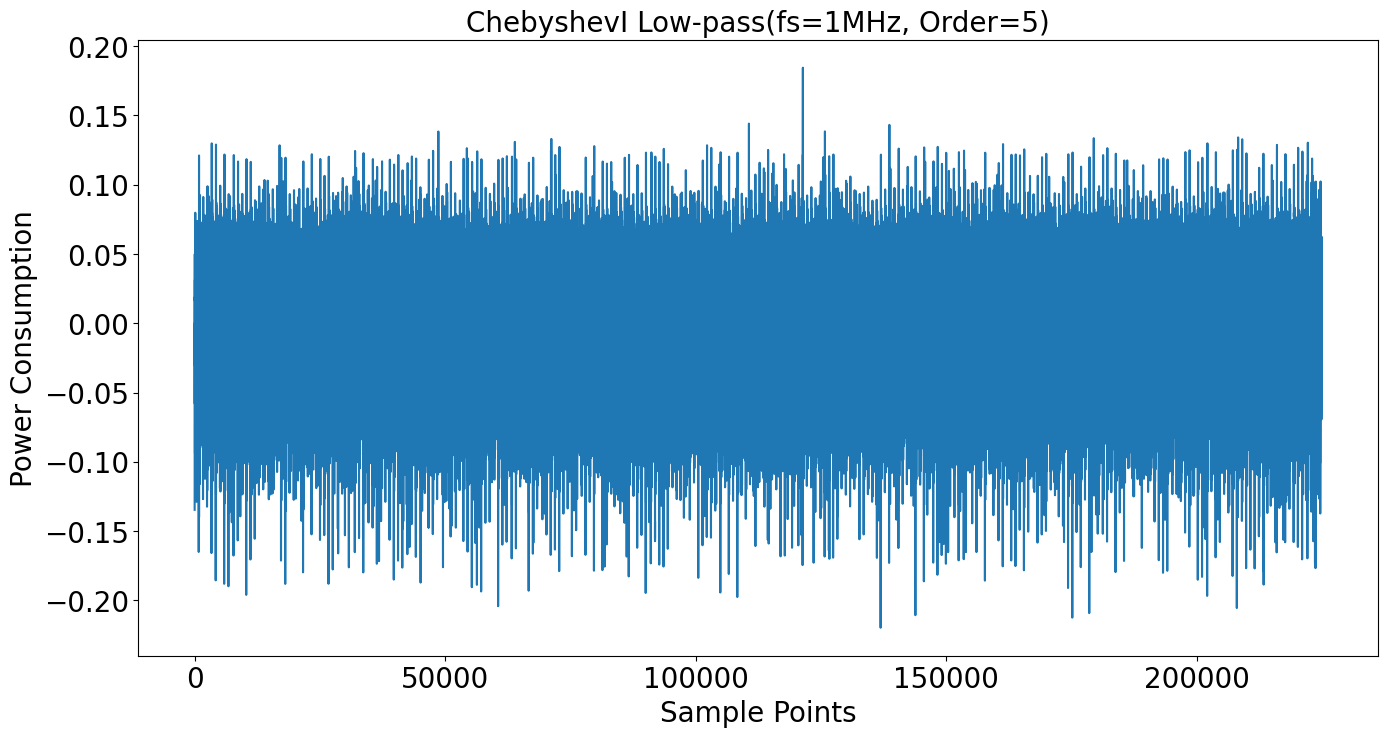

In [15]:
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.title('ChebyshevI Low-pass(fs=1MHz, Order=5)',fontsize=20)
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Power Consumption', fontsize=20)
# plt.plot(filtered_traces_array[0, 100:])
plt.plot(filtered_traces_array[0])
plt.savefig(f'figure/chebyshev_lowpass/single_trace_ChebyshevI_filter.png', dpi=200, bbox_inches='tight')

#### 濾波後平均

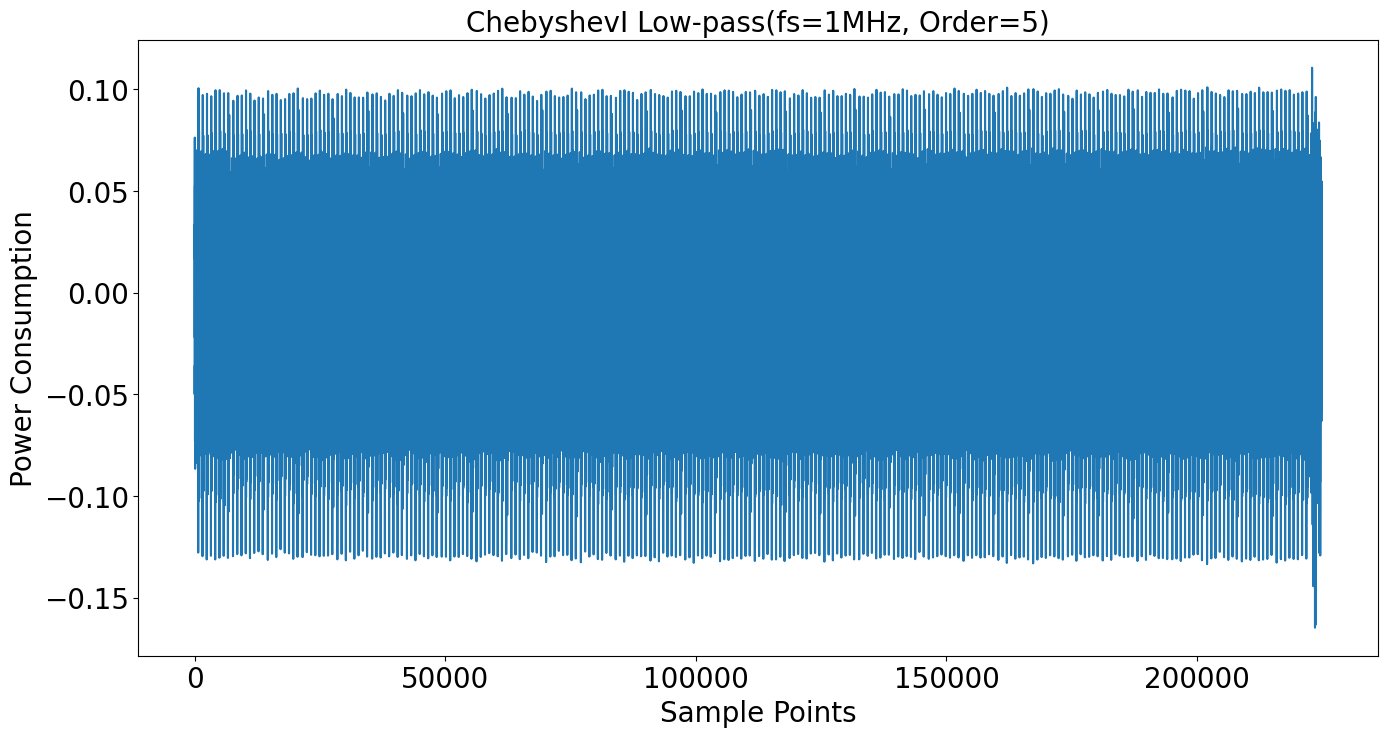

In [11]:
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.title('ChebyshevI Low-pass(fs=1MHz, Order=5)',fontsize=20)
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Power Consumption', fontsize=20)
plt.plot(np.mean(filtered_traces_array, axis=0)[100:])
plt.savefig(f'figure/chebyshev_lowpass/mean_trace_ChebyshevI_filter.png', dpi=200, bbox_inches='tight')

#### 濾波後比較

Text(0, 0.5, 'Power Consumption')

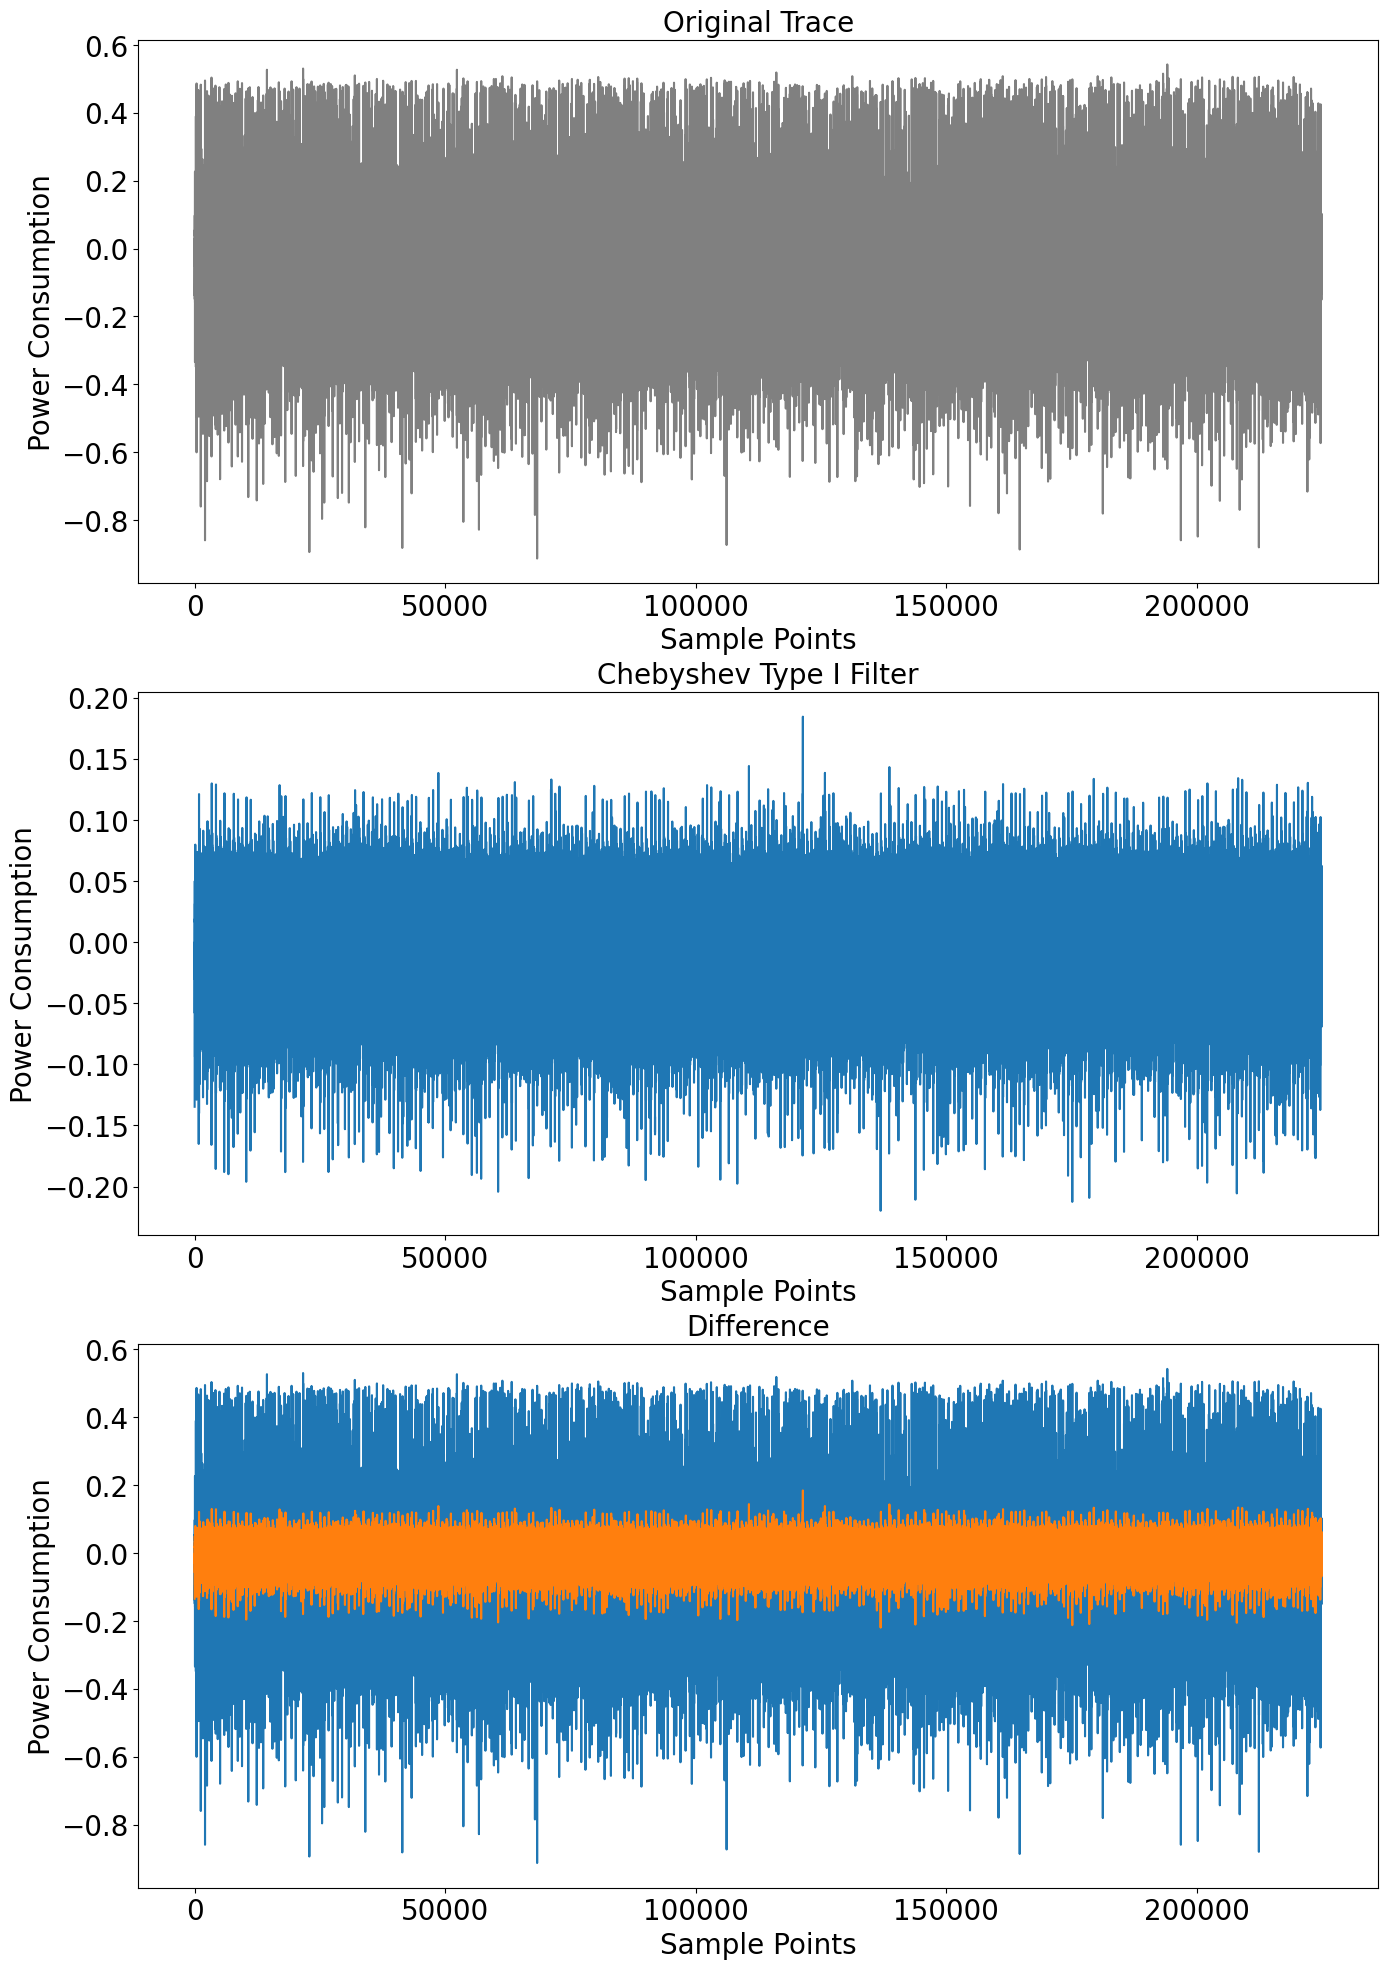

In [12]:
plt.figure(figsize=(16, 24))

plt.subplot(3, 1, 1)
plt.plot(t[0], color='gray')
plt.title('Original Trace', fontsize=20)
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Power Consumption', fontsize=20)

plt.subplot(3, 1, 2)
plt.plot(filtered_traces_array[0])
plt.title('Chebyshev Type I Filter', fontsize=20)
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Power Consumption', fontsize=20)

plt.subplot(3, 1, 3)
plt.plot(t[0])
plt.plot(filtered_traces_array[0])
plt.title('Difference', fontsize=20)
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Power Consumption', fontsize=20)


# plt.savefig(f'figure/trace_lowpass_filter_remove_noise/PQClean_unfixed_message_{trace_num}_single_trace_compare.png', dpi=200, bbox_inches='tight')

Text(0, 0.5, 'Power Consumption')

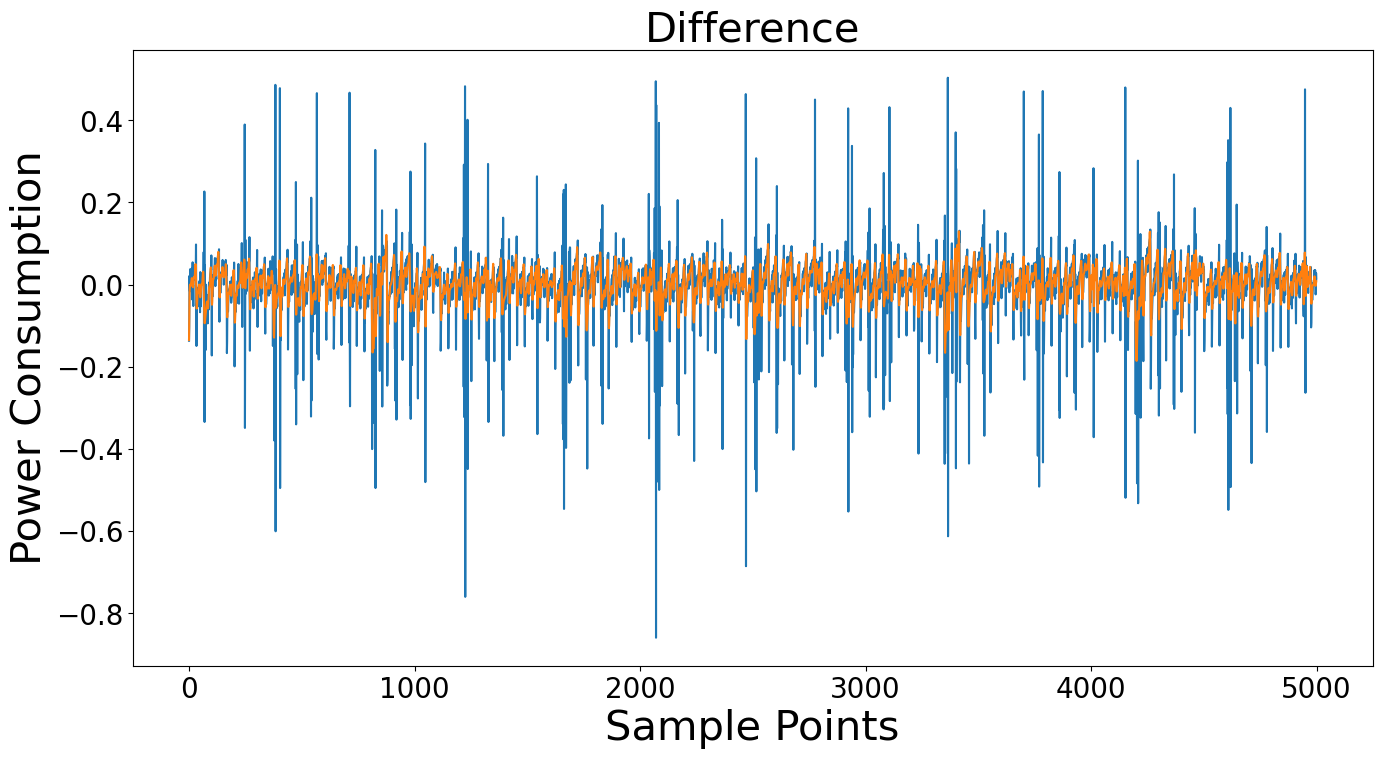

In [13]:
plt.figure(figsize=(16, 8))
plt.plot(t[0, :5000])
plt.plot(filtered_traces_array[0, :5000])
plt.title('Difference', fontsize=30)
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=30)
plt.ylabel('Power Consumption', fontsize=30)